## Load Packages

In [1]:
import scipy
import numpy as np
import xarray as xr
import pandas as pd

from dissipationIFR.config import plotting_style, VMP_variables
from dissipationIFR import utilities, tools, interactive
#plotting_style = "/Users/u302042/Desktop/DissipationIFR/dissipationIFR/dissipationIFR/config/plotting.mplstyle"

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

import os

## 1. Converting VMP data to netCDF format

In [2]:
path = "/Users/u302042/Desktop/Master_thesis/Data/VMP/"
file = "ALLMERGED.mat"
data = scipy.io.loadmat(path + file)

In [3]:
ds_VMP = utilities.create_vmp_dataset(data, VMP_variables)

In [4]:
N = tools.calc_n(ds_VMP.PRES.values, density=ds_VMP.SIGTHETA.values, lat=ds_VMP.LATITUDE.values, lon=ds_VMP.LONGITUDE.values)
ds_VMP["N"] = (("N_MEASUREMENTS"), N)

In [5]:
savefile = "All_VMP.nc"
delete_existing = False  # Set to True to delete existing file, False to keep it
### check if file already exists and delete it if it does
if os.path.exists(path + savefile):
    if delete_existing:
        os.remove(path + savefile)
        print(f"Deleted existing file: {path + savefile}\n Saving new file...")
        ds_VMP.to_netcdf(path + savefile)
    else:
        print(f"File already exists: {path + savefile}. Not deleting.")
else:
    print(f"Saving new file: {path + savefile}...")
    ds_VMP.to_netcdf(path + savefile)
    

File already exists: /Users/u302042/Desktop/Master_thesis/Data/VMP/All_VMP.nc. Not deleting.


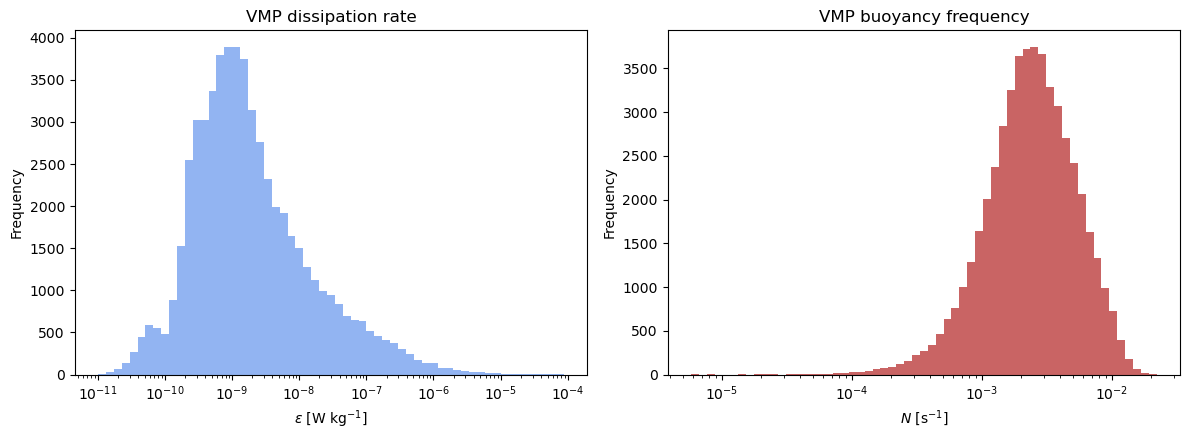

In [6]:
eps = ds_VMP["EPSILON"].values.ravel()
n = ds_VMP["N"].values.ravel()

eps = eps[np.isfinite(eps)]
n = n[np.isfinite(n)]

# Use logarithmic bins for epsilon and linear bins for buoyancy frequency
eps_bins = np.logspace(np.log10(np.min(eps)), np.log10(np.max(eps)), 60)
n_bins = np.logspace(np.log10(np.min(n)), np.log10(np.max(n)), 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(eps, bins=eps_bins, alpha=0.7, color="cornflowerblue")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\epsilon$ [W kg$^{-1}$]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("VMP dissipation rate")

axes[1].hist(n, bins=n_bins, alpha=0.7, color="firebrick")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$N$ [s$^{-1}$]")
axes[1].set_ylabel("Frequency")
axes[1].set_title("VMP buoyancy frequency")

plt.tight_layout()
plt.show()

## 2. Open sg005 data and cut it to region of VMP casts

In [7]:
sg005_path = "/Users/u302042/Desktop/Master_thesis/Data/Glider/005/20080606/"
sg005_file = "gridded_ownfm.nc"
sg005_file = "gridded_bs3.nc"
glider = xr.open_dataset(sg005_path + sg005_file)
### add cast number to sg005 dataset, always two profiles are one cast (e.g profile 1 and 2 are cast 1)
glider['CAST'] = (np.ceil(glider.PROFILE_NUMBER/2)).astype(int)

VMP = xr.open_dataset(path + savefile)

In [8]:
# load bathymetry for bottom depth and plotting
bathymetry = xr.open_dataset("/Users/u302042/Desktop/Master_thesis/Data/Bathymetry/GEBCO_2024_IFR.nc")

for ds in [VMP, glider]:
    dims = list(ds.sizes.keys())[0]
    lon, lat = ds.LONGITUDE, ds.LATITUDE
    elevation = bathymetry['elevation'].sel(lon=lon, lat=lat, method='nearest')
    ds['BATHYMETRY'] = elevation
    depth = ds.DEPTH
    ds['HEIGHT_ABOVE_BOTTOM'] = -(depth + elevation)

In [9]:
# Apply glider mask for better comparison with VMP data
excluded_casts = [93, 146, 75, 76, 85, 187, 188, 189, 190]
glider_mask = ((glider.LATITUDE.values > 60) & (glider.LATITUDE.values < 61.98)
    & (glider.TIME.values >= np.datetime64("2008-06-06T20:00")) & (glider.TIME.values <= np.datetime64("2008-07-22T10:00"))
    & (~glider.CAST.isin(excluded_casts))
)
glider = glider.sel(N_MEASUREMENTS=glider_mask)

# Remove the first sixteen VMP profiles and keep only deep measurements
vmp_mask = ((VMP.PROFILE_NUMBER.values >= 16) & (VMP.BATHYMETRY.values <= -700))
VMP = VMP.sel(N_MEASUREMENTS=vmp_mask)


[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1000. 1100.
 1200. 1300. 1400.]


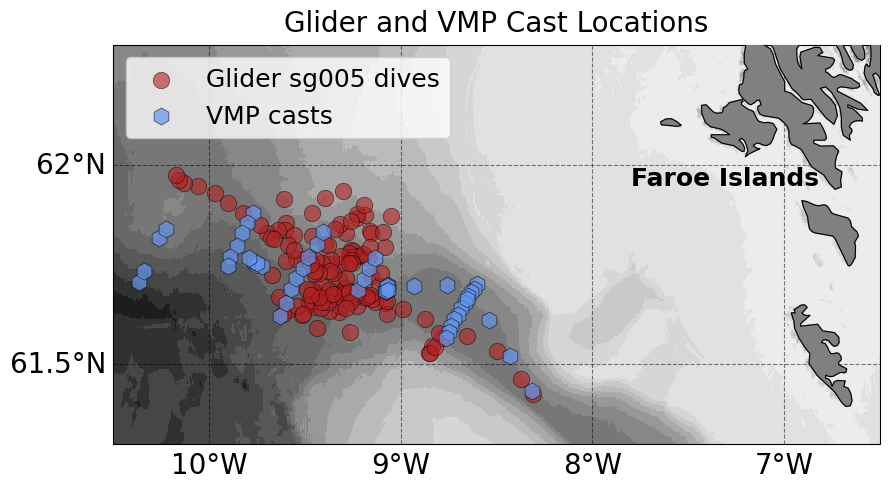

In [10]:
latitudes = glider.LATITUDE.groupby(glider.CAST).mean().values
longitudes = glider.LONGITUDE.groupby(glider.CAST).mean().values
times = glider.TIME.groupby(glider.CAST).mean().values
profile_numbers = glider.CAST.groupby(glider.CAST).mean().values

 # Data to plot
VMP_lat = VMP.LATITUDE.groupby(VMP.PROFILE_NUMBER).mean().values
VMP_lon = VMP.LONGITUDE.groupby(VMP.PROFILE_NUMBER).mean().values

# Set the colorbar mode: either 'TIME' or 'PROFILES'
#color_mode = 'TIME'

map_kw = ccrs.PlateCarree()
# Prepare figure and axis
with plt.style.context(plotting_style):
    fig, ax = plt.subplots(subplot_kw={"projection": map_kw}, figsize=(9, 5))

    # Bounding box
    lon_min, lon_max = -10.5, -6.5
    lat_min, lat_max = 61.3, 62.3
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=map_kw)
    ax.set_aspect("auto")

    # Bathymetry background
    bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
    levels, contour_levels, max_level = tools.get_bathymetry_levels(bath,level_spacing=100)
    print(levels)
    base_cmap = plt.get_cmap("Greys")
    cmap_bath = mcolors.LinearSegmentedColormap.from_list("dark_greys", base_cmap(np.linspace(0.15, 0.9, len(levels))))
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_bath.N)
    ax.pcolormesh(
        bath.lon, bath.lat, abs(bath.elevation.values),
        cmap=cmap_bath, norm=norm, transform=ccrs.PlateCarree(), zorder=1
    )

    # Glider scatter
    ax.scatter(
        longitudes, latitudes,alpha=0.6,
        color="firebrick", s=140, marker='o', label="Glider sg005 dives", edgecolors="black", linewidths=0.5
    )

    ax.scatter(
        VMP_lon, VMP_lat,alpha=0.7,
        color="cornflowerblue", s=150, marker='h', label="VMP casts", edgecolors="black", linewidths=0.5
    )

    # Final plot settings
    ax.legend(loc='upper left', fontsize=18)

    ax.add_feature(cfeature.LAND, color="gray", zorder=10)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, color="black", alpha=0.5, linestyle="--")
    gl.xlocator = mticker.FixedLocator([-11, -10, -9 , -8,-7, -6])
    gl.ylocator = mticker.FixedLocator([61.5, 62])
    #### make ticks bigger
    gl.xlabel_style = {'size': 20}
    gl.ylabel_style = {'size': 20}
    gl.top_labels = False
    gl.right_labels = False

    ax.text(x=-7.8, y=61.95, s="Faroe Islands", fontsize= 18,weight='bold',zorder = 100)

plt.title("Glider and VMP Cast Locations", fontsize=20, pad = 10)
plt.tight_layout()
plt.grid()
plt.show()

## 3. Compare VMP and sg005 data for different layers

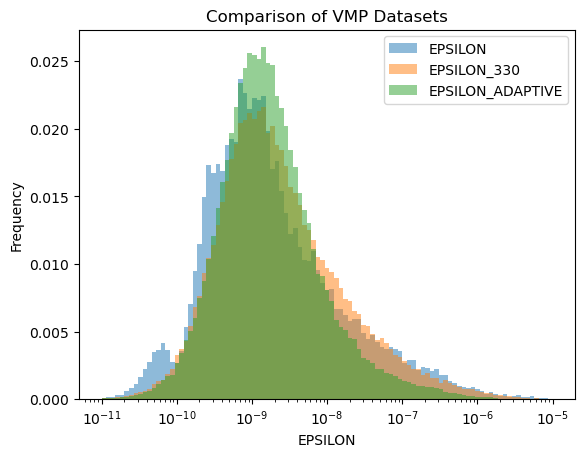

In [11]:
bins = np.logspace(-11, -5, 100)  # Define logarithmically spaced bins
for var in ['EPSILON', 'EPSILON_330', 'EPSILON_ADAPTIVE']:
    if var == 'EPSILON':
        ds = VMP
        factor = 1.0  # No scaling needed for VMP data
    else:
        ds = glider
        factor = 0.06  # Adjust this factor based on your data
    weights = np.ones_like(ds[var].values.flatten()) / len(ds[var].values.flatten())
    plt.hist(ds[var].values.flatten() * factor, bins=bins, alpha=0.5, label=var, weights=weights)
plt.xlabel('EPSILON')
plt.ylabel('Frequency')
plt.title('Comparison of VMP Datasets')
plt.legend()
plt.xscale('log')
plt.show()

## 3.1 Assign layer acronyms and save VMP dataset

In [12]:
import numpy as np
import xarray as xr
from tqdm import tqdm


def find_layer_boundaries(profile_numbers, temp, depth):
    """
    Find OL and AL boundaries for each profile.

    Returns
    -------
    profiles : ndarray
        Unique profile numbers.
    boundary_OL : ndarray
        OL boundary depth for each profile.
    boundary_AL : ndarray
        AL boundary depth for each profile.
    """
    profiles = np.unique(profile_numbers)

    boundary_OL = np.full(profiles.size, np.nan)
    boundary_AL = np.full(profiles.size, np.nan)

    for i, profile in enumerate(tqdm(profiles)):
        mask = profile_numbers == profile
        T = temp[mask]
        z = depth[mask]

        valid = ~np.isnan(T) & ~np.isnan(z)
        T = T[valid]
        z = z[valid]

        if len(T) < 2:
            continue

        order = np.argsort(z)
        T = T[order]
        z = z[order]

        dTdz = np.gradient(T, z)

        # Overflow Layer boundary
        ol = (T < 3) & (np.abs(dTdz) < 0.004)
        if np.any(ol):
            boundary_OL[i] = z[ol].min()

        # Atlantic Layer boundary
        al = (T > 7.7) & (np.abs(dTdz) < 0.01) & (z > 50)
        if np.any(al):
            boundary_AL[i] = z[al].max()

    return profiles, boundary_OL, boundary_AL

def assign_layers(ds):
    """
    Add a variable 'LAYER' to the dataset.

    Layers are:
        AL : DEPTH <= AL boundary
        IL : AL boundary < DEPTH < OL boundary
        OL : DEPTH >= OL boundary

    If OL is missing, IL extends to the deepest observation.
    """

    profiles, boundary_OL, boundary_AL = find_layer_boundaries(
        ds.PROFILE_NUMBER.values,
        ds.TEMP.values,
        ds.DEPTH.values,
    )

    layer = np.full(ds.sizes[list(ds.dims)[0]], "", dtype="U2")

    for i, profile in enumerate(profiles):

        mask = ds.PROFILE_NUMBER.values == profile
        depth = ds.DEPTH.values[mask]

        ol = boundary_OL[i]
        al = boundary_AL[i]

        profile_layer = np.full(depth.shape, "", dtype="U2")

        if not np.isnan(al):
            profile_layer[depth <= al] = "AL"

        if np.isnan(ol):
            ol = np.inf

        profile_layer[(depth > al) & (depth < ol)] = "IL"
        profile_layer[depth >= ol] = "OL"

        layer[mask] = profile_layer

    ds = ds.assign(LAYER=(list(ds.dims)[0], layer))

    return ds

In [13]:
VMP = assign_layers(VMP)
glider = assign_layers(glider)

  0%|          | 0/272 [00:00<?, ?it/s]/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/u302042/miniconda3/envs/dissipationIFR/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \
100%|██████████| 272/272 [00:00<00:00, 9860.76it/s]


In [15]:
### save VMP dataset with layer information1
savefile = "All_VMP.nc"
delete_existing = False  # Set to True to delete existing file, False to keep it
### check if file already exists and delete it if it does
if os.path.exists(path + savefile):
    if delete_existing:
        os.remove(path + savefile)
        print(f"Deleted existing file: {path + savefile}\n Saving new file...")
        VMP.to_netcdf(path + savefile)
    else:
        print(f"File already exists: {path + savefile}. Not deleting.")
else:
    print(f"Saving new file: {path + savefile}...")
    VMP.to_netcdf(path + savefile)

File already exists: /Users/u302042/Desktop/Master_thesis/Data/VMP/All_VMP.nc. Not deleting.


In [21]:
eps_rms = tools.rolling_rms(VMP.EPSILON.values, VMP.TIME.values, VMP.PROFILE_NUMBER.values, window_size_seconds = 100)
VMP['EPSILON_RMS'] = (('N_MEASUREMENTS'), eps_rms)

Computing RMS: 100%|██████████| 62/62 [00:00<00:00, 12171.06it/s]


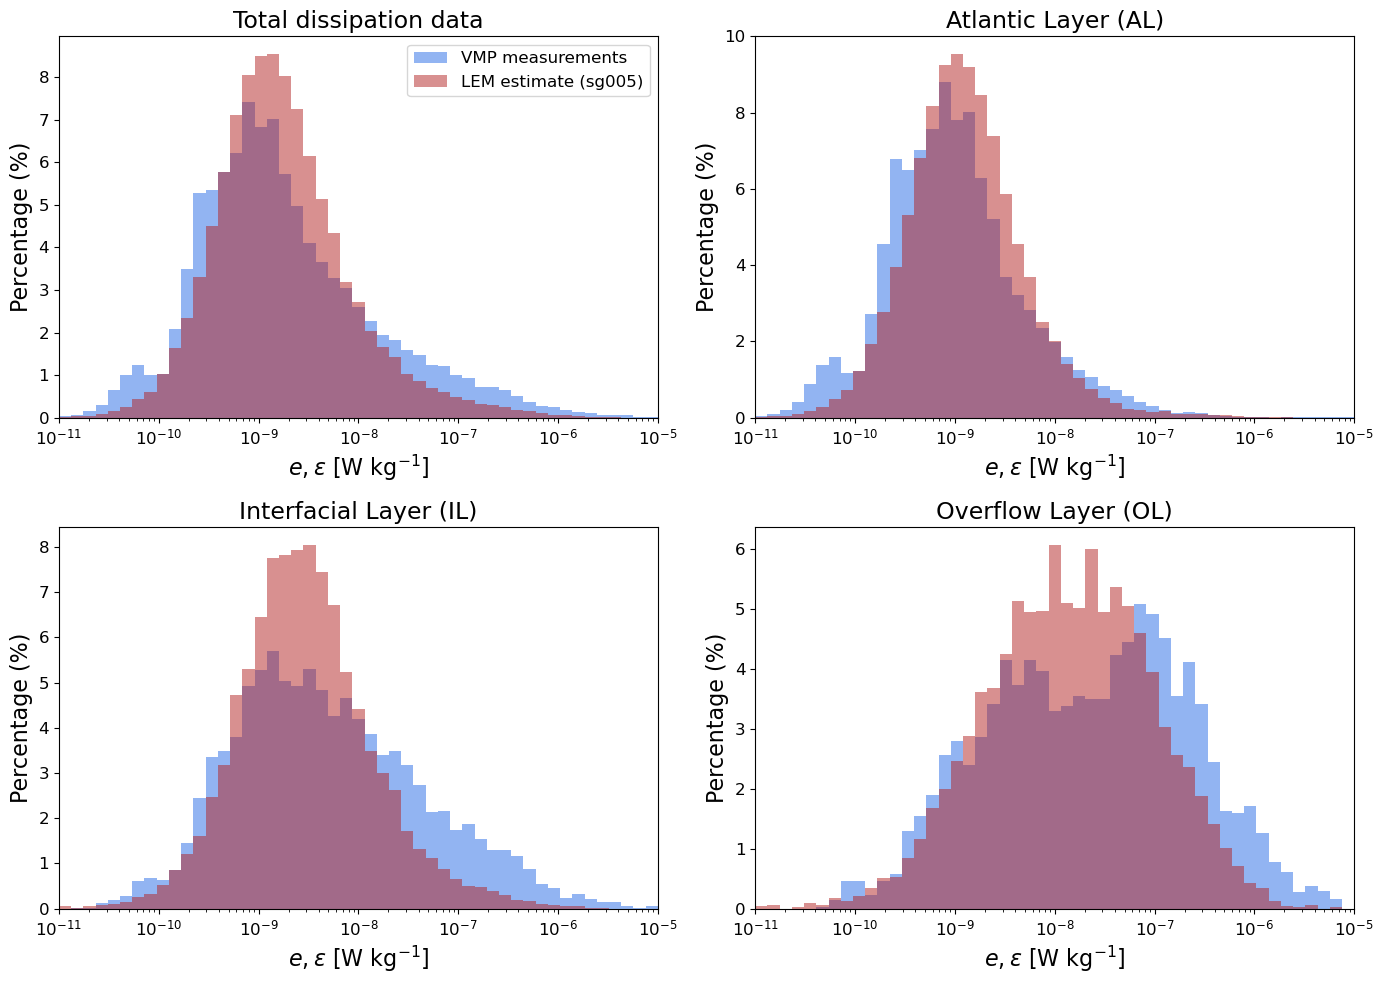

In [23]:
with plt.style.context(plotting_style):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    var_VMP = "EPSILON"
    var_glider = "EPSILON_ADAPTIVE"

    layers = [
        (None, "Total dissipation data"),
        ("AL", "Atlantic Layer (AL)"),
        ("IL", "Interfacial Layer (IL)"),
        ("OL", "Overflow Layer (OL)")
    ]

    bins = np.logspace(-11, -5, 50)

    for ax, (layer, title) in zip(axes, layers):

        if layer is None:
            ds_g = glider
            ds_v = VMP
        else:
            g_msk, V_msk = (glider.LAYER == layer), (VMP.LAYER == layer)
            ds_g = glider.sel(N_MEASUREMENTS=g_msk)
            ds_v = VMP.sel(N_MEASUREMENTS=V_msk)

        # VMP
        VMP_data = ds_v[var_VMP].values
        VMP_data = VMP_data[~np.isnan(VMP_data)]
        weights = np.ones_like(VMP_data) / len(VMP_data) * 100

        ax.hist(VMP_data, bins=bins, alpha=0.7, color="cornflowerblue", label="VMP measurements", weights=weights,)

        # Glider
        glider_data = ds_g[var_glider].values
        glider_data = glider_data[~np.isnan(glider_data)]
        weights = np.ones_like(glider_data) / len(glider_data) * 100

        ax.hist(glider_data * 0.06, bins=bins, alpha=0.5, color="firebrick", label="LEM estimate (sg005)", weights=weights,)

        ax.set_title(title, fontsize=17)

    for ax in axes:
        ax.set_xlabel(r"$e, \epsilon$ [W kg$^{-1}$]", fontsize=16)
        ax.set_ylabel("Percentage (%)", fontsize=16)
        ax.set_xscale("log")
        ax.set_xlim(1e-11, 1e-5)

    axes[0].legend(fontsize=12)
    plt.tight_layout()

# plt.savefig(thesis_resources_path + '/VMP_sg005_histogram.png',
#             dpi=300, bbox_inches='tight')
plt.show()

In [116]:
### calculate N for glider and VMP data
n = 1
N = tools.calc_n(VMP.PRES.values, density=VMP.SIGTHETA.values, lat=VMP.LATITUDE.values, lon=VMP.LONGITUDE.values, n=n)
VMP["N"] = (("N_MEASUREMENTS"), N)
n = 1
N = tools.calc_n(glider.PRES.values, temp = glider.TEMP.values, salinity=glider.PSAL.values, lat=glider.LATITUDE.values, lon=glider.LONGITUDE.values, n=n)
glider["N"] = (("N_MEASUREMENTS"), N)


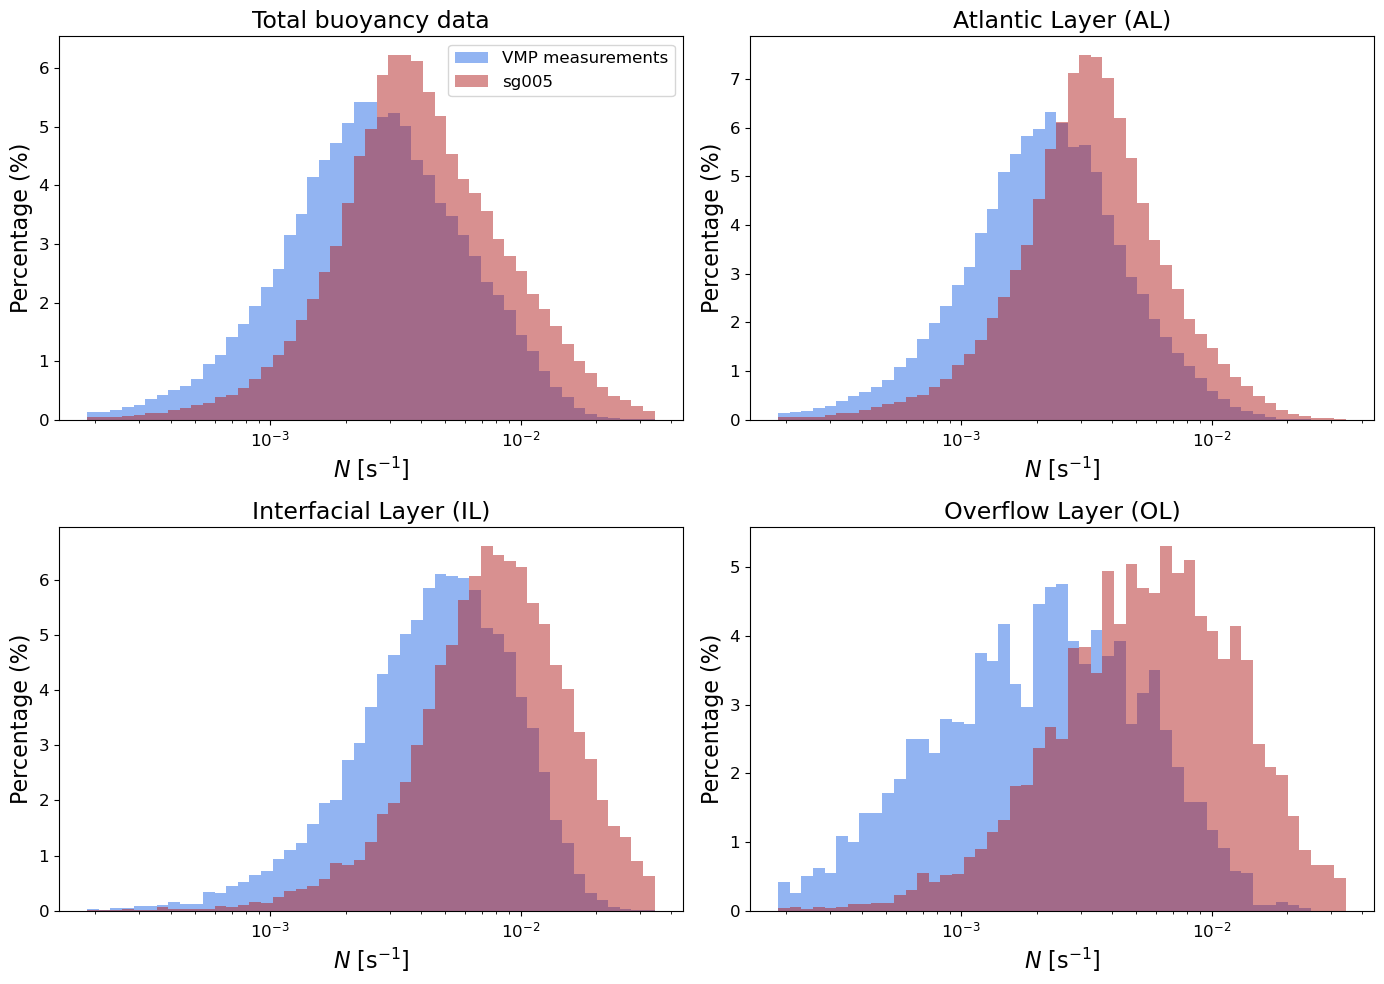

In [117]:
with plt.style.context(plotting_style):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    var_VMP = "N"
    var_glider = "N"

    layers = [
        (None, "Total buoyancy data"),
        ("AL", "Atlantic Layer (AL)"),
        ("IL", "Interfacial Layer (IL)"),
        ("OL", "Overflow Layer (OL)")
    ]

    VMP_min, VMP_max = np.nanpercentile(VMP[var_VMP].values, 0.5), np.nanpercentile(VMP[var_VMP].values, 99.5)
    glider_min, glider_max = np.nanpercentile(glider[var_glider].values, 0.5), np.nanpercentile(glider[var_glider].values, 99.5)
    min_value = min(VMP_min, glider_min)
    max_value = max(VMP_max, glider_max)

    bins = np.logspace(np.log10(min_value), np.log10(max_value), 50)

    for ax, (layer, title) in zip(axes, layers):

        if layer is None:
            ds_g = glider
            ds_v = VMP
        else:
            g_msk, V_msk = (glider.LAYER == layer), (VMP.LAYER == layer)
            ds_g = glider.sel(N_MEASUREMENTS=g_msk)
            ds_v = VMP.sel(N_MEASUREMENTS=V_msk)

        # VMP
        VMP_data = ds_v[var_VMP].values
        VMP_data = VMP_data[~np.isnan(VMP_data)]
        weights = np.ones_like(VMP_data) / len(VMP_data) * 100

        ax.hist(VMP_data, bins=bins, alpha=0.7, color="cornflowerblue", label="VMP measurements", weights=weights,)

        # Glider
        glider_data = ds_g[var_glider].values
        glider_data = glider_data[~np.isnan(glider_data)]
        weights = np.ones_like(glider_data) / len(glider_data) * 100

        ax.hist(glider_data, bins=bins, alpha=0.5, color="firebrick", label="sg005", weights=weights,)

        ax.set_title(title, fontsize=17)

    for ax in axes:
        ax.set_xlabel(r"$N$ [s$^{-1}$]", fontsize=16)
        ax.set_ylabel("Percentage (%)", fontsize=16)
        ax.set_xscale("log")
        #ax.set_xlim(1e-6, 1e-2)

    axes[0].legend(fontsize=12)
    plt.tight_layout()

# plt.savefig(thesis_resources_path + '/VMP_sg005_histogram.png',
#             dpi=300, bbox_inches='tight')
plt.show()